# Predicting autism risk genes — end-to-end demo

This notebook runs the core of the project on public data, in a few minutes on a laptop (no GPU):

1. build the positive (SFARI Gene) and negative (Krishnan et al. 2016) gene labels used in the thesis;
2. load the ProtT5 protein embeddings computed during the thesis;
3. evaluate a classifier with cross-validation and show why the thesis under-reported its AUC;
4. check whether the thesis rankings anticipated the genes SFARI added between 2024 and 2026.

Every input is downloaded and checksum-verified by `asd fetch`. Only the 2026 SFARI release must be downloaded by hand (SFARI terms of use).

In [1]:
import json
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from asd_gene_predict.config import load_config
from asd_gene_predict.data import labels as lb
from asd_gene_predict.data.sources import fetch, load_sources, select_sources
from asd_gene_predict.embeddings.io import embedding_path, load_embeddings, save_embeddings
from asd_gene_predict.embeddings.legacy import LEGACY_META, read_legacy
from asd_gene_predict.models import evaluate as ev
from asd_gene_predict.validation import temporal as tv

ACCENT, OLD, GRAPH, BASE, INK = "#0b6d77", "#98a8af", "#cf5f27", "#a9b0b2", "#12191c"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
cfg = load_config()
src = load_sources()
logging.getLogger("asd_gene_predict").setLevel(logging.ERROR)

## 1. Data

Download the inputs (pinned to a commit of the original thesis repository) and verify their SHA-256.

In [2]:
needed = [
    "sfari",
    "krishnan_2016",
    "legacy_prott5",
    "legacy_rank_protein",
    "legacy_rank_graph",
    "legacy_peptides",
]
for r in fetch(select_sources(src, needed)):
    print(f"{r.status.value:>10}  {r.source.name}")

        ok  sfari
        ok  krishnan_2016
        ok  legacy_prott5
        ok  legacy_rank_protein
        ok  legacy_rank_graph
        ok  legacy_peptides


### Labels

Positives are SFARI genes (release of 16 Jan 2024); negatives are the Krishnan et al. genes not in SFARI. The thesis compared several positive sets; every model is tested on the same `cat_1` genes.

In [3]:
labels = lb.build_labels(
    lb.read_sfari(src["sfari"].path()),
    lb.read_krishnan(src["krishnan_2016"].path()),
    lb.load_exclusions(),
)
lb.save_labels(labels)
lb.summarize(labels, lb.positive_sets(cfg))

,set,positives,negatives
0,cat_1,231,790
1,cat_1_sd,325,790
2,cat_1_2,935,790
3,cat_1_2_sd,1029,790
4,cat_1_2_3,1066,790
5,complete,1160,790


### Protein embeddings

One 1024-dimensional ProtT5 vector per gene (mean-pooled over the canonical protein), as computed in the thesis.

In [4]:
emb = read_legacy(src["legacy_prott5"].path())
save_embeddings(emb, embedding_path("protein_prott5"), LEGACY_META["prott5"])
X = load_embeddings(embedding_path("protein_prott5"))
print(f"{X.shape[0]} genes x {X.shape[1]} dimensions")

1940 genes x 1024 dimensions


## 2. Cross-validated evaluation

Nested cross-validation as in the thesis: 5 stratified folds over the `cat_1` genes, hyperparameters tuned inside each training fold, scaling fitted on training data only.

The thesis computed ROC-AUC and average precision on hard 0/1 predictions. The pipeline keeps that value (`roc_auc_legacy`) next to the correct one, computed on predicted probabilities.

In [5]:
sets = [s for s in lb.positive_sets(cfg) if s.name == "cat_1"]
res = ev.cross_validate(X, labels, sets, ["lr"], seed=cfg["seed"])
cols = ["roc_auc_legacy", "roc_auc", "ap_legacy", "average_precision", "mcc"]
res[cols].agg(["mean", "std"]).round(3)

,roc_auc_legacy,roc_auc,ap_legacy,average_precision,mcc
mean,0.830,0.910,0.536,0.765,0.599
std,0.037,0.017,0.057,0.065,0.067


With the thesis formula the AUC is ~0.83, the number reported in the thesis. With probabilities it is ~0.91. The MCC, which never depended on that formula, is unchanged.

The reason: an AUC computed on 0/1 predictions keeps a single point of the ROC curve, and the area under that triangle equals the average of sensitivity and specificity.

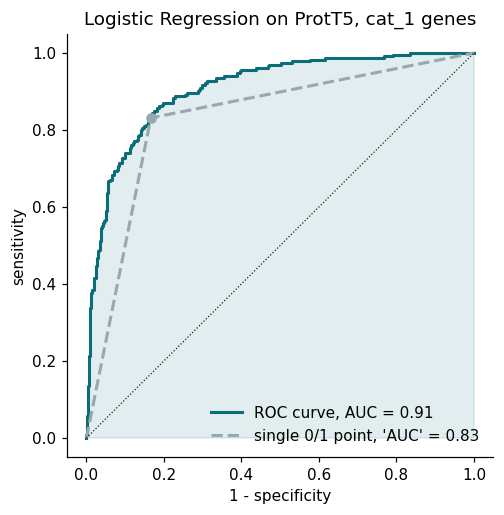

In [6]:
C = float(pd.Series([json.loads(p)["C"] for p in res["best_params"]]).mode()[0])
data = lb.select_set(labels[labels.ensembl_gene_id.isin(X.index)], sets[0])
Xa, y = X.loc[data.ensembl_gene_id].to_numpy(), data.label.to_numpy()
model = make_pipeline(
    StandardScaler(), LogisticRegression(C=C, class_weight="balanced", max_iter=5000)
)
proba = cross_val_predict(
    model,
    Xa,
    y,
    cv=StratifiedKFold(5, shuffle=True, random_state=cfg["seed"]),
    method="predict_proba",
)[:, 1]
pred = (proba >= 0.5).astype(int)
fpr, tpr, _ = roc_curve(y, proba)
sens, spec = (pred[y == 1] == 1).mean(), (pred[y == 0] == 0).mean()

fig, ax = plt.subplots(figsize=(5, 5))
ax.fill_between(fpr, tpr, color=ACCENT, alpha=0.12)
ax.plot(fpr, tpr, color=ACCENT, lw=2, label=f"ROC curve, AUC = {roc_auc_score(y, proba):.2f}")
ax.plot(
    [0, 1 - spec, 1],
    [0, sens, 1],
    color=OLD,
    lw=2,
    ls="--",
    label=f"single 0/1 point, 'AUC' = {roc_auc_score(y, pred):.2f}",
)
ax.scatter([1 - spec], [sens], color=OLD, zorder=3)
ax.plot([0, 1], [0, 1], color=INK, lw=0.8, ls=":")
ax.set(
    xlabel="1 - specificity",
    ylabel="sensitivity",
    title="Logistic Regression on ProtT5, cat_1 genes",
)
ax.legend(frameon=False, loc="lower right")
plt.show()

## 3. Temporal validation

The thesis ranked ~19,000 genes with a model trained on the January 2024 SFARI release. Since then SFARI has added new genes that the model never saw. If the ranking is useful, those genes should sit near the top.

Baseline: ordering genes by protein length alone. Long genes collect more de novo variants and are discovered more often, so a useful model has to beat this.

In [7]:
sfari_new = Path(os.environ.get("ASD_SFARI_NEW", src["sfari_2026q2"].path()))
assert sfari_new.exists(), f"Download the current SFARI 'Human Gene' CSV to {sfari_new}"

old = lb.read_sfari(src["sfari"].path())
new = lb.read_sfari(sfari_new)
added = tv.new_genes(old, new)
exclude = set(old.ensembl_gene_id) | set(lb.read_krishnan(src["krishnan_2016"].path()))
length = tv.protein_length(src["legacy_peptides"].path())
scores = {
    "Protein (ProtT5)": tv.read_legacy_ranking(src["legacy_rank_protein"].path()),
    "Graph (DeepWalk)": tv.read_legacy_ranking(src["legacy_rank_graph"].path()),
    "Protein length (baseline)": length,
}
table = tv.compare(scores, set(added.ensembl_gene_id), exclude, confounder=length)
print(f"{len(added)} genes added to SFARI since January 2024")
table[
    ["n_pool", "n_new", "auc", "auc_adjusted", "top1_frac", "top10_frac", "median_percentile"]
].astype(float).round(3)

127 genes added to SFARI since January 2024


,n_pool,n_new,auc,auc_adjusted,top1_frac,top10_frac,median_percentile
score,,,,,,,
Protein (ProtT5),16274.0,108.0,0.844,0.797,0.148,0.546,0.916
Graph (DeepWalk),16274.0,108.0,0.801,0.763,0.120,0.491,0.896
Protein length (baseline),16274.0,108.0,0.786,0.647,0.130,0.463,0.880


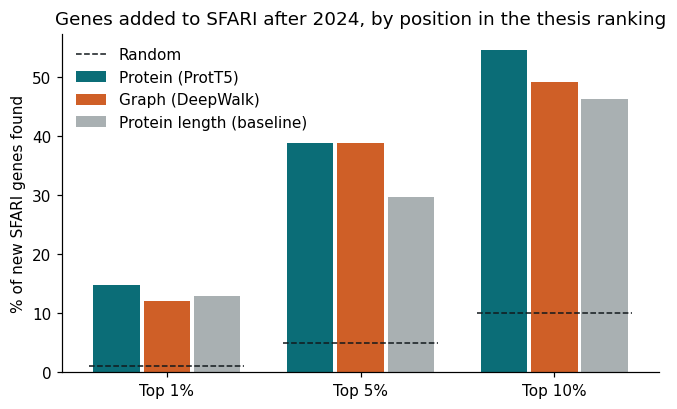

AUC protein - AUC length = +0.053 (95% CI +0.012 to +0.098)


In [8]:
tops = ["top1", "top5", "top10"]
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
for i, (name, color) in enumerate(zip(table.index, [ACCENT, GRAPH, BASE], strict=True)):
    vals = [100 * table.loc[name, f"{t}_frac"] for t in tops]
    ax.bar(x + (i - 1) * 0.26, vals, 0.24, color=color, label=name)
for xi, r in zip(x, [1, 5, 10], strict=True):
    ax.hlines(
        r, xi - 0.4, xi + 0.4, colors=INK, linestyles="--", lw=1, label="Random" if r == 1 else None
    )
ax.set_xticks(x, ["Top 1%", "Top 5%", "Top 10%"])
ax.set_ylabel("% of new SFARI genes found")
ax.set_title("Genes added to SFARI after 2024, by position in the thesis ranking")
ax.legend(frameon=False)
plt.show()

diff, lo, hi = tv.bootstrap_auc_diff(
    scores["Protein (ProtT5)"][~scores["Protein (ProtT5)"].index.isin(exclude)],
    length,
    set(added.ensembl_gene_id),
)
print(f"AUC protein - AUC length = {diff:+.3f} (95% CI {lo:+.3f} to {hi:+.3f})")

In [9]:
symbol = dict(zip(new.ensembl_gene_id, new.symbol, strict=True))
hits = tv.top_hits(scores["Protein (ProtT5)"], set(added.ensembl_gene_id), exclude, n=50)
print(
    "New SFARI genes among the top 50 unlabelled genes of the protein ranking:",
    ", ".join(symbol[g] for g in hits),
)

New SFARI genes among the top 50 unlabelled genes of the protein ranking: CHD4, BPTF, DOP1A, DOT1L, FRYL, RALGAPA1, ZNF532


## Takeaways

- The rewrite reproduces the thesis numbers; with the AUC computed on probabilities, performance is substantially higher (AUC ~0.91, AUPRC ~0.77).
- The thesis protein ranking anticipated the genes SFARI added two years later: about half of them were in the top 10% of ~16,000 unlabelled genes.
- Protein length explains part of that signal, but the protein embeddings still add information beyond it.

Full reports: [`reports/prott5_reproduction.md`](../reports/prott5_reproduction.md), [`reports/temporal_validation.md`](../reports/temporal_validation.md), [`docs/changes_from_thesis.md`](../docs/changes_from_thesis.md).